<a href="https://colab.research.google.com/github/FrancescoBalzan/T-S_Coadaptation_Computational_Model_/blob/main/CAEO_computational_model_of_teacher_student_co_adaptation_rebuttal_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Title: A Computational Model of Teacher-Student Co-adaptation
International Journal of Artificial Intelligence in Education
Autors: Francesco Balzan; Pedro P. Santos, Maurizio Gabbrielli, Mahault Albarracin, Manuel Lopes.
Corresponding author: Francesco Balzan, University of Bologna
email: francesco.balzan3@unibo.it

In [ ]:
import numpy as np
import random

np.random.seed(45)
np.printoptions(2)

import matplotlib.pyplot as plt
import matplotlib

import seaborn as sns
sns.set_style("dark")

#matplotlib.rcParams['text.usetex'] =  True
plt.rc('text.latex', preamble=r'\usepackage{pifont}')
matplotlib.rcParams.update({'font.size': 16})
sns.set_palette("colorblind")

In [ ]:
def entropy(d):
    return np.sum(-d*np.log(d+1e-10))

def generate_dataset(S, pf):
    # Args:
    # S - target number of concepts.
    # pf (shape: [num_features]) - probability that each feature is active for each concept.
    D = np.random.random((S,pf.shape[0])) < pf
    D = np.unique(D, axis=0)
    Nc = D.shape[0] # Actual number of concepts after removing duplicates.
    Nf = D.shape[1] # Number of features.
    # print('Nc:', Nc, 'Nf:', Nf)
    return D, Nc, Nf

pf_test = np.array([0.2,0.3,0.4,0.5,0.6,0.7,0.1,0.4,0.4,0.9,0.8,0.7,0.1,0.2,0.3])
D_test, Nc_test, Nf_test = generate_dataset(S=240, pf=pf_test)

# Test dataset generation.
# D = np.array([[0,0,0,0], [1,0,1,1], [0,0,0,1], [0,0,1,0]])
# Nc = D.shape[0] # Number of concepts.
# Nf = D.shape[1] # Number of features.
# print(D.shape)
# print(D)

In [ ]:
class OptTeacher():

    def __init__(self, target, D):
        # Args:
        # - target (type: int) - target concept.
        # - D (shape: [num_concepts,num_features]) dataset.
        self.D = D
        self.Nc, self.Nf = D.shape
        self.target = target
        self.h = D[target,:] # features for the target concept.
        self.fs = [] # stores features that were already suggested.

        self.p = np.ones(self.Nc) / self.Nc # uniform probability distribution over all concepts.

        self.updated_p = None

    def select2teach(self, non_observed_features=None, estimated_features_observability=None):
        # If `estimated_features_observability` then the info gains are weighted given
        # the probabilities in `estimated_features_observability`.

        if len(np.where(self.p == 1)[0]) == 1:
            return -1, [] # if self.p is a one-hot vector -> stop.

        # Compute matrix containing the differences between each of the features
        # of the target concept and all other concepts.
        diff_matrix = np.copy(self.D)
        for ff in np.arange(self.Nf):
            diff_matrix[:,ff] = (self.D[:,ff] == self.h[ff])

            # Mask out concepts that already have zero probability under self.p.
            diff_matrix[:,ff] = diff_matrix[:,ff] * self.p

        # Calculate updated `p` vectors for each of the features.
        # Each column of `updated_ps` has the updated self.p distribution
        # if the teacher were to suggest the student to ask for the column's feature.
        updated_ps = diff_matrix / np.sum(diff_matrix,axis=0)

        # Calculate the information gain for each of the new `p` vectors
        # (for each column of matrix `updated_ps`).
        updated_ps_entropy = np.sum(-updated_ps * np.log(updated_ps + 1e-10), axis=0)
        info_gains = entropy(self.p) - updated_ps_entropy

        # Mask out features the teacher already knows that are non-observed by the student (over the given interaction).
        if non_observed_features:
            for non_obs_f in non_observed_features:
                info_gains[non_obs_f] = 0

        # If `estimated_features_observability` then calculate the *expected* information gain for each feature.
        if np.all(estimated_features_observability):
            info_gains = info_gains * estimated_features_observability

        # Pick feature that has the highest (expected) information gain.
        optimal_feature = np.argmax(info_gains)
        self.fs.append(optimal_feature)

        # Store updated distribution.
        self.updated_p = updated_ps[:,optimal_feature]

        return optimal_feature, self.h[optimal_feature]

    def answerstudent(self, nf):

        # Integrate feedback given student's question.
        fval = self.h[nf]
        self.p[np.where(self.D[:,nf] != fval)[0]] = 0 # Zero-out concepts that are not compatible with feature `nf` having value `fval`.
        self.p = self.p / np.sum(self.p) # Re-normalize.

        return fval

    def update_p(self):
        # Update self.p to be the new distribution according to the optimal feature chosen.
        self.p = np.copy(self.updated_p)

In [ ]:
class ActLearner():

    def __init__(self, D, non_observed_features):
        # Args:
        # - D (shape: [num_concepts,num_features]) dataset.
        # - non_observed_features (shape: [num_features]) - 1 indicates the learner sees the feature, otherwise (value 0) it does not see the feature.
        self.Nc, self.Nf = D.shape
        self.non_observed_features = non_observed_features
        self.D = D @ np.diag(non_observed_features) # Create masked dataset according to the features the learned does not see (parametrized by `non_observed_features`).
        self.h = -np.ones(self.Nf) # features for target concept that the learner already knows (-1 = unknown).
        self.asked_fs = [] # list to store asked features.
        self.received_fs = [] # list to store features the teacher told the learner.

        # Probability distribution over concepts.
        self.p = np.ones((self.Nc)) / self.Nc

    def select2ask(self):

        # Calculate expected information gain for each of the features.
        info_gains = np.zeros(self.Nf)
        for ff in np.arange(self.Nf):

            if ff in self.asked_fs:
                continue # Skip feature that was already asked (info gain = 0).

            # If ff = True.
            masked_D_ff = self.D[:,ff] * self.p # Mask concepts that are not possible anymore.
            prob_t = np.sum((masked_D_ff > 0)) / np.sum((self.p > 0)) # probability of ff = True.
            if prob_t > 0:
                p_new_t = (masked_D_ff > 0)
                p_new_t = p_new_t / np.sum(p_new_t)
            else:
                p_new_t = np.zeros_like(masked_D_ff) # this does not really matter because prob_t=0.

            # If ff = False.
            prob_f = 1 - prob_t
            if prob_f > 0:
                p_new_f = (self.D[:,ff] == 0)
                p_new_f = p_new_f * self.p # Mask out concepts that are not possible anymore.
                p_new_f = p_new_f / np.sum(p_new_f)
            else:
                p_new_f = np.zeros_like(masked_D_ff) # this does not really matter because prob_f=0.

            info_gains[ff] = entropy(self.p) - (prob_t*entropy(p_new_t) + prob_f*entropy(p_new_f))

        # Pick feature that leads to the maximum information gain.
        nf = np.argmax(info_gains)
        self.asked_fs.append(nf)

        return nf

    def integratefeedback(self, nf, fval):

        # The learner cannot understand these features.
        if self.non_observed_features[nf] == 0:
            return np.max(self.p) # Quit (return most-likely concept).

        # Store feature that is now known.
        self.h[nf] = fval
        self.received_fs.append(nf)

        # Update vector of probabilities over concepts.
        self.p[np.where(self.D[:,nf] != fval)[0]] = 0 # Zero-out concepts that are not compatible with feature `nf` having value `fval`.
        self.p = self.p / np.sum(self.p) # Re-normalize.

        return np.max(self.p) # Return the probability of the most-likely concept.


In [ ]:
def only_active_learning(teacher, students, dataset, Nc, Nf, target_concept, estimated_features_observability):

    non_observed_features_by_the_students = []
    observed_features_by_the_students = []
    number_of_done_students_list = []

    students_num_interactions_until_done = {s : np.nan for s in students}

    num_done_students = 0
    for ii in np.arange(Nf):

        # Student's turn.
        students_that_did_not_learn_yet = [std for std in students if np.max(std.p) < 0.99]
        random_student = np.random.choice(students_that_did_not_learn_yet)
        nf = random_student.select2ask()

        fval = teacher.answerstudent(nf)

        # Integrate feedback for all students.
        for s in students:
              s.integratefeedback(nf, fval)

        all_students_done = True
        for std in students:
            val_std = np.max(std.p)
            if val_std < 0.99:
                all_students_done = False
            elif np.isnan(students_num_interactions_until_done[std]):
                # Student learned the concept *now*.
                students_num_interactions_until_done[std] = ii
                num_done_students += 1

        number_of_done_students_list.append(num_done_students)

        if all_students_done:
            break # All students learned the concept and want to stop.

    number_of_done_students_list = number_of_done_students_list + [number_of_done_students_list[-1]]*(Nf - len(number_of_done_students_list)) # pad to length=Nf by repeating the last number in the list.
    percentage_of_done_students = np.array(number_of_done_students_list) / len(students) # shape: [number_interactions,]

    num_correct_students = np.sum(np.array([(np.argmax(student.p) == target_concept) for student in students]))

    students_num_interactions_until_done = np.array(list(students_num_interactions_until_done.values()))
    avg_num_interactions = np.mean(students_num_interactions_until_done[~np.isnan(students_num_interactions_until_done)]) # Remove students that didn't learn the concept (nan entries).

    return num_correct_students, avg_num_interactions+1, observed_features_by_the_students, non_observed_features_by_the_students, percentage_of_done_students


def interact_with_group_only_teaching(teacher, students, dataset, Nc, Nf, target_concept, estimated_features_observability):

    non_observed_features_by_the_students = []
    observed_features_by_the_students = []
    number_of_done_students_list = []

    students_num_interactions_until_done = {s : np.nan for s in students}

    num_done_students = 0
    for ii in np.arange(Nf):

        # Sample a given target student to interact (the one that replies back to the teacher).
        target_student = np.random.choice(students)

        nf, fval = teacher.select2teach(non_observed_features=non_observed_features_by_the_students,
                                        estimated_features_observability=estimated_features_observability)

        if nf == -1:
            break # teacher is done.

        else:

            # Integrate feedback for all students.
            for s in students:
                  s.integratefeedback(nf, fval)

            # Target student replies acknowledging whether he sees the feature or not.
            if target_student.non_observed_features[nf] == 0:
                # The student does not observe this feature.
                non_observed_features_by_the_students.append(nf)
            else:
                # The student observes this feature.
                teacher.update_p() # Teacher updates the internal probability distribution over the characters after the acknowledgment from the student.
                observed_features_by_the_students.append(nf)

            all_students_done = True
            for std in students:
                val_std = np.max(std.p)
                if val_std < 0.99:
                    all_students_done = False
                elif np.isnan(students_num_interactions_until_done[std]):
                    # Student learned the concept *now*.
                    students_num_interactions_until_done[std] = ii
                    num_done_students += 1

            number_of_done_students_list.append(num_done_students)
            if all_students_done:
                break # All students learned the concept and want to stop.

    num_correct_students = np.sum(np.array([(np.argmax(student.p) == target_concept) for student in students]))

    number_of_done_students_list = number_of_done_students_list + [number_of_done_students_list[-1]]*(Nf - len(number_of_done_students_list)) # pad to length=Nf by repeating the last number in the list.
    percentage_of_done_students = np.array(number_of_done_students_list) / len(students) # shape: [number_interactions,]

    students_num_interactions_until_done = np.array(list(students_num_interactions_until_done.values()))
    avg_num_interactions = np.mean(students_num_interactions_until_done[~np.isnan(students_num_interactions_until_done)]) # Remove students that didn't learn the concept (nan entries).

    return num_correct_students, avg_num_interactions+1, observed_features_by_the_students, non_observed_features_by_the_students, percentage_of_done_students


def interact_with_group_teaching_and_learning(teacher, students, dataset, Nc, Nf, target_concept, estimated_features_observability):

    non_observed_features_by_the_students = []
    observed_features_by_the_students = []
    number_of_done_students_list = []

    teacher_initiative = True
    teacher_finished = False

    students_num_interactions_until_done = {s : np.nan for s in students}

    num_done_students = 0
    for ii in np.arange(Nf):

        if teacher_initiative and not teacher_finished:
            # Teacher's turn.

            # Sample a given target student to interact (the one that replies back to the teacher).
            target_student = np.random.choice(students)

            nf, fval = teacher.select2teach(non_observed_features=non_observed_features_by_the_students,
                                            estimated_features_observability=estimated_features_observability)

            if nf == -1:
                teacher_finished = True # Teacher stopped.

            else:

                # Integrate feedback for all students.
                for s in students:
                      s.integratefeedback(nf, fval)

                # Target student replies acknowledging whether he sees the feature or not.
                if target_student.non_observed_features[nf] == 0:
                    # The student does not observe this feature.
                    non_observed_features_by_the_students.append(nf)
                    teacher_initiative = False
                else:
                    # The student observes this feature.
                    teacher.update_p() # Teacher updates the internal probability distribution over the characters after the acknowledgment from the student.
                    observed_features_by_the_students.append(nf)

                all_students_done = True
                for std in students:
                    val_std = np.max(std.p)
                    if val_std < 0.99:
                        all_students_done = False
                    elif np.isnan(students_num_interactions_until_done[std]):
                        # Student learned the concept *now*.
                        students_num_interactions_until_done[std] = ii
                        num_done_students += 1

                number_of_done_students_list.append(num_done_students)

                if all_students_done:
                    break # All students learned the concept and want to stop.

        else:
            # Student's turn: a randomly sampled student among those that still did not learn the concept asks a question.

            students_that_did_not_learn_yet = [std for std in students if np.max(std.p) < 0.99]
            random_student = np.random.choice(students_that_did_not_learn_yet)
            nf = random_student.select2ask()

            fval = teacher.answerstudent(nf)

            # Integrate feedback for all students.
            for s in students:
                  s.integratefeedback(nf, fval)


            all_students_done = True
            for std in students:
                val_std = np.max(std.p)
                if val_std < 0.99:
                    all_students_done = False
                elif np.isnan(students_num_interactions_until_done[std]):
                    # Student learned the concept *now*.
                    students_num_interactions_until_done[std] = ii
                    num_done_students += 1

            number_of_done_students_list.append(num_done_students)

            if all_students_done:
                break # All students learned the concept and want to stop.

            # After student's question, switch back to teacher's initiative (if teacher is not done yet).
            teacher_initiative = True

    number_of_done_students_list = number_of_done_students_list + [number_of_done_students_list[-1]]*(Nf - len(number_of_done_students_list)) # pad to length=Nf by repeating the last number in the list.
    percentage_of_done_students = np.array(number_of_done_students_list) / len(students) # shape: [number_interactions,]

    num_correct_students = np.sum(np.array([(np.argmax(student.p) == target_concept) for student in students]))

    students_num_interactions_until_done = np.array(list(students_num_interactions_until_done.values()))
    avg_num_interactions = np.mean(students_num_interactions_until_done[~np.isnan(students_num_interactions_until_done)]) # Remove students that didn't learn the concept (nan entries).

    return num_correct_students, avg_num_interactions+1, observed_features_by_the_students, non_observed_features_by_the_students, percentage_of_done_students


def generate_dataset_and_learners(S, pf, num_groups, num_learners_types,
                                  num_learner_disabled_features, force_dataset_learnability):
    # Args:
    # S - target number of concepts.
    # pf (shape: [num_features]) - probability that each feature is active for each concept.
    # num_groups (type: int) - number of groups of students/learners.
    # num_learners_types (type: int) - number of types of students/learners to consider.
    # num_learner_disabled_features - number of features that are randomly disabled for each of the learners
    #             (for the experimental settings where the student and the teacher do not share features).
    # force_dataset_learnability (type: bool) - if True, only datasets that are learnable from the
    #              perspective of the student are considered.

    # Generate the set of features that are disabled for each type of learner.
    disabled_features_per_learner_type = []
    for g in range(num_learners_types):
        disabled_features_idxs = np.random.choice(range(len(pf)), size=num_learner_disabled_features, replace=False)
        disabled_features_per_learner_type.append(disabled_features_idxs)

    # Generate dataset.
    if force_dataset_learnability:
        dataset, _, _ = generate_dataset(S=S, pf=pf)

        for g in range(num_learners_types):
            cutted_dataset = np.delete(dataset, disabled_features_per_learner_type[g], axis=1)
            _, unique_rows_idxs = np.unique(cutted_dataset, axis=0, return_index=True)
            dataset = dataset[unique_rows_idxs,:]

        Nc, Nf = dataset.shape
    else:
        dataset, Nc, Nf = generate_dataset(S=S, pf=pf)

    print('Generated dataset:')
    print('Nc:', Nc, 'Nf:', Nf)
    print('disabled_features_per_learner_type:', disabled_features_per_learner_type)

    return Nc, Nf, dataset, disabled_features_per_learner_type


def interaction(S, pf, num_interactions_with_groups, num_learners_types, num_learner_disabled_features,
                num_groups, num_students_per_group, prob_type_given_group, force_dataset_learnability,
                adaptive_group_teaching, interaction_f):
    # Args:
    # S - target number of concepts.
    # pf (shape: [num_features]) - probability that each feature is active for each concept.
    # num_interactions_with_groups (type: int) - number of interactions between the teacher and each of the groups.
    # num_learners_types (type: int) - number of types of students/learners to consider.
    # num_learner_disabled_features - number of features that are randomly disabled for each of the learners
    #             (for the experimental settings where the student and the teacher do not share features).
    # num_groups (type: int) - number of groups.
    # num_students_per_group (type: int) - number of students per group.
    # prob_type_given_group (type: np.array) - probability that each student type belongs to each group.
    # force_dataset_learnability (type: bool) - if True, only datasets that are learnable from the
    #              perspective of the student are considered.
    # adaptive_group_teaching (type: bool) - if True then the teacher weights the info_gains according to the
    #               estimated probabilities that the student sees each feature (given the group).
    # interaction_f: function to implement the interaction between the teacher and the groups
    #                (see `interact_with_group_teaching_and_learning` and `interact_with_group_only_teaching` for examples).

    # Setup.
    Nc, Nf, dataset, disabled_features_per_learner_type = generate_dataset_and_learners(S=S,
                pf=pf,
                num_groups=num_groups,
                num_learners_types=num_learners_types,
                num_learner_disabled_features=num_learner_disabled_features,
                force_dataset_learnability=force_dataset_learnability)

    # Assert groups/types dimensions.
    assert(num_groups == prob_type_given_group.shape[0])
    assert(num_learners_types == prob_type_given_group.shape[1])

    observed_features_counter = np.ones((num_groups, Nf))
    non_observed_features_counter = np.ones((num_groups, Nf))

    students_groups_types = {}
    # Create groups of students.
    for group in range(num_groups):
        students_groups_types[group] = [np.random.choice(range(num_learners_types), p=prob_type_given_group[group])
                                      for _ in range(num_students_per_group)]
    print('students_groups_types:', students_groups_types)

    DATA_LOG = {}
    DATA_LOG["observed_features_counter"] = np.zeros((num_interactions_with_groups, num_groups, Nf))
    DATA_LOG["non_observed_features_counter"] = np.zeros((num_interactions_with_groups, num_groups, Nf))
    DATA_LOG["is_correct"] = np.zeros([num_interactions_with_groups, num_groups])
    DATA_LOG["num_interactions"] = np.zeros([num_interactions_with_groups, num_groups])
    DATA_LOG["disabled_features_per_learner_type"] = disabled_features_per_learner_type
    DATA_LOG["percentage_of_done_students"] = np.zeros((num_interactions_with_groups, num_groups, Nf))

    for i in range(num_interactions_with_groups):

        # Sample a given target concept to teach.
        target_concept = np.random.choice(range(Nc))

        # Interact with each group.
        for group in range(num_groups):

            # Create vector that has the probability that the teacher thinks the students see each of the features, given the group.
            # Based on information contained in `observed_features_counter` and  `non_observed_features_counter` vectors.
            # Based on the idea of Thompson sampling.
            estimated_features_observability = np.array([np.random.beta(observed_features_counter[group, f_idx],
                                                              non_observed_features_counter[group, f_idx]) for f_idx in range(Nf)])

            # Interact with group.
            teacher = OptTeacher(target_concept, dataset)
            students = []
            for student_type in students_groups_types[group]:
                Fsi = np.ones(Nf)
                Fsi[disabled_features_per_learner_type[student_type]] = 0
                student = ActLearner(dataset, Fsi)
                students.append(student)

            if adaptive_group_teaching:
                num_correct_students, num_interactions, observed_features_by_the_students, non_observed_features_by_the_students, percentage_of_done_students = \
                        interaction_f(teacher, students, dataset, Nc, Nf, target_concept, estimated_features_observability)
            else:
                num_correct_students, num_interactions, observed_features_by_the_students, non_observed_features_by_the_students, percentage_of_done_students = \
                        interaction_f(teacher, students, dataset, Nc, Nf, target_concept, None)

            for feature_idx in observed_features_by_the_students:
                observed_features_counter[group, feature_idx] += 1
            for feature_idx in non_observed_features_by_the_students:
                non_observed_features_counter[group, feature_idx] += 1

            DATA_LOG["num_interactions"][i,group] = num_interactions
            DATA_LOG["is_correct"][i,group] = num_correct_students / num_students_per_group # percentage of correct students.
            DATA_LOG["percentage_of_done_students"][i,group] = percentage_of_done_students # percentage of correct students (across timesteps).

        DATA_LOG["observed_features_counter"][i,:,:] = observed_features_counter
        DATA_LOG["non_observed_features_counter"][i,:,:] = non_observed_features_counter

    return DATA_LOG


def run_multiple_exps(num_exps, interaction_f_args):

    data_logs = [interaction(**interaction_f_args) for _ in range(num_exps)]

    merged_data_logs = {}
    for k in data_logs[0].keys():
        data_key = [data_logs[i][k] for i in range(len(data_logs))]
        merged_data_logs[k] = np.array(data_key)

    return merged_data_logs # shape [num_exps, ... , ...]

In [ ]:
NUM_EXPS = 100
interaction_f_args = {"S": 500,
            "num_interactions_with_groups": 41,
            "pf": np.array([0.2,0.3,0.4,0.5,0.6,0.7,0.1,0.4,0.4,0.9,0.8,0.7,0.5,0.6,0.2]),
            "num_learners_types": 3,
            "num_learner_disabled_features": 5,
            "num_groups": 3,
            "num_students_per_group": 30,
            "prob_type_given_group": np.array([[0.9,0.05,0.05], [0.05,0.9,0.05], [0.05,0.05,0.9]]),
            "force_dataset_learnability": True,
            "adaptive_group_teaching": True, # If False then the teacher does not adapt to groups.
            "interaction_f": interact_with_group_only_teaching, # `interact_with_group_teaching_and_learning`, `interact_with_group_only_teaching`, or `only_active_learning`
            }

interaction_f_args["adaptive_group_teaching"] = True
interaction_f_args["interaction_f"] = interact_with_group_only_teaching
log_data_teach_adaptive = run_multiple_exps(num_exps=NUM_EXPS, interaction_f_args=interaction_f_args)

interaction_f_args["adaptive_group_teaching"] = False
interaction_f_args["interaction_f"] = interact_with_group_only_teaching
log_data_teach_non_adaptive = run_multiple_exps(num_exps=NUM_EXPS, interaction_f_args=interaction_f_args)

interaction_f_args["adaptive_group_teaching"] = True
interaction_f_args["interaction_f"] = interact_with_group_teaching_and_learning
log_data_teach_learn_adaptive = run_multiple_exps(num_exps=NUM_EXPS, interaction_f_args=interaction_f_args)

interaction_f_args["adaptive_group_teaching"] = False
interaction_f_args["interaction_f"] = interact_with_group_teaching_and_learning
log_data_teach_learn_non_adaptive = run_multiple_exps(num_exps=NUM_EXPS, interaction_f_args=interaction_f_args)

interaction_f_args["adaptive_group_teaching"] = False # This parameter is irrelevant when using only active learning.
interaction_f_args["interaction_f"] = only_active_learning
log_data_only_learn = run_multiple_exps(num_exps=NUM_EXPS, interaction_f_args=interaction_f_args)

Generated dataset:
Nc: 158 Nf: 15
disabled_features_per_learner_type: [array([ 7,  9, 12,  8,  5]), array([ 3,  1,  6,  5, 10]), array([ 2,  0,  6, 11,  3])]
students_groups_types: {0: [np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)], 1: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1)], 2: [np.int64(2), np.int64(2)

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Generated dataset:
Nc: 162 Nf: 15
disabled_features_per_learner_type: [array([10,  0, 12,  9,  7]), array([ 1,  2,  0, 10,  6]), array([ 2, 14,  9,  1,  4])]
students_groups_types: {0: [np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)], 1: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)], 2: [np.int64(2), np.int64(2)

In [ ]:
def nanmean_cols(x):
    mask = ~np.isnan(x)
    x_masked = np.where(mask, x, 0)
    return x_masked.sum(0)/mask.sum(0)

# 95 % mean bootstrapped confidence interval.
def mean_ci(samples: np.ndarray, num_resamples: int=30_000):
    # Point estimation.
    point_estimate = np.mean(samples)
    # Confidence interval estimation.
    resampled = np.random.choice(samples,
                                size=(len(samples), num_resamples),
                                replace=True)
    point_estimations = np.mean(resampled, axis=0)
    confidence_interval = [np.percentile(point_estimations, 2.5),
                           np.percentile(point_estimations, 97.5)]
    return confidence_interval

def nanmean_ci_cols(x):
    # x shape: [num_samples, num_timesteps]
    cis = []
    for t in range(x.shape[1]):
        x_filtered = x[~np.isnan(x[:,t]), t]
        cis.append(mean_ci(x_filtered))
    return np.array(cis)

### Teacher-students interaction plot

num_exps 100
num_interactions_with_groups 41
num_groups 3
Nf 15


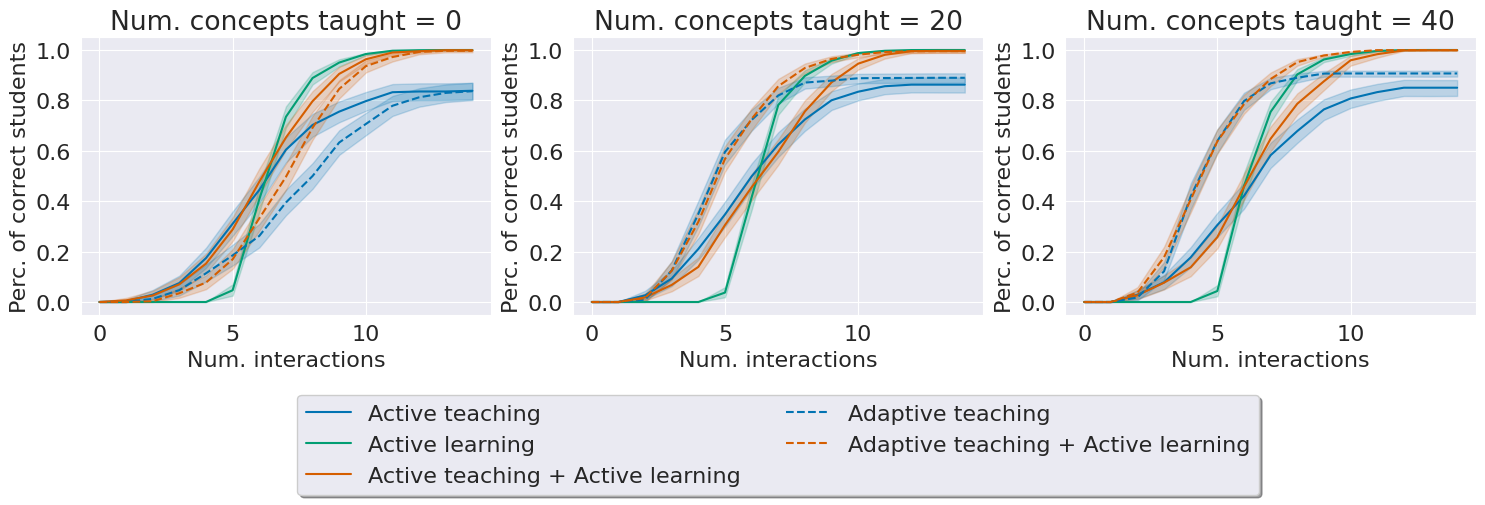

In [ ]:
line_colors = {
    "Active teaching": (0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
    "Adaptive teaching": (0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
    "Active teaching + Active learning": (0.8352941176470589, 0.3686274509803922, 0.0),
    "Adaptive teaching + Active learning": (0.8352941176470589, 0.3686274509803922, 0.0),
    "Active learning": (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
}

line_styles= {
    "Active teaching": '-',
    "Adaptive teaching": '--',
    "Active teaching + Active learning": '-',
    "Adaptive teaching + Active learning": '--',
    "Active learning": '-',
}

num_exps, num_interactions_with_groups, num_groups, Nf = log_data_teach_adaptive["observed_features_counter"].shape
print("num_exps", num_exps)
print("num_interactions_with_groups", num_interactions_with_groups)
print("num_groups", num_groups)
print("Nf", Nf)

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18, 4))
#fig.tight_layout()

num_concepts_taught_idxs_to_slice = [0, 20, 40]

# Axis 0
lbls = ["Active teaching", "Active learning", "Active teaching + Active learning", "Adaptive teaching", "Adaptive teaching + Active learning"]
for data, lbl in zip([log_data_teach_non_adaptive["percentage_of_done_students"], log_data_only_learn["percentage_of_done_students"], log_data_teach_learn_non_adaptive["percentage_of_done_students"], log_data_teach_adaptive["percentage_of_done_students"], log_data_teach_learn_adaptive["percentage_of_done_students"]], lbls):
    # Plot mean.
    data_to_plot = data[:,num_concepts_taught_idxs_to_slice[0],:,:]
    data_to_plot = data_to_plot.reshape(-1, Nf)
    y_mean = np.mean(data_to_plot, axis=0)

    line, = axs[0].plot(y_mean, label=lbl, color=line_colors[lbl], linestyle=line_styles[lbl])

    # Plot bootstrapped confidence interval.
    cis = nanmean_ci_cols(data_to_plot)
    axs[0].fill_between(np.arange(Nf), cis[:,0], cis[:,1], alpha=0.2, color=line.get_color())

axs[0].grid()
axs[0].set_ylabel("Perc. of correct students")
axs[0].set_xlabel("Num. interactions")
axs[0].set_title(f"Num. concepts taught = {num_concepts_taught_idxs_to_slice[0]}")

# Axis 1
for data, lbl in zip([log_data_teach_non_adaptive["percentage_of_done_students"], log_data_only_learn["percentage_of_done_students"], log_data_teach_learn_non_adaptive["percentage_of_done_students"], log_data_teach_adaptive["percentage_of_done_students"], log_data_teach_learn_adaptive["percentage_of_done_students"]], lbls):
    # Plot mean.
    data_to_plot = data[:,num_concepts_taught_idxs_to_slice[1],:,:]
    data_to_plot = data_to_plot.reshape(-1, Nf)
    y_mean = np.mean(data_to_plot, axis=0)

    line, = axs[1].plot(y_mean, label=lbl, color=line_colors[lbl], linestyle=line_styles[lbl])

    # Plot bootstrapped confidence interval.
    cis = nanmean_ci_cols(data_to_plot)
    axs[1].fill_between(np.arange(Nf), cis[:,0], cis[:,1], alpha=0.2, color=line.get_color())

axs[1].grid()
axs[1].set_ylabel("Perc. of correct students")
axs[1].set_xlabel("Num. interactions")
axs[1].set_title(f"Num. concepts taught = {num_concepts_taught_idxs_to_slice[1]}")

# Axis 2
for data, lbl in zip([log_data_teach_non_adaptive["percentage_of_done_students"], log_data_only_learn["percentage_of_done_students"], log_data_teach_learn_non_adaptive["percentage_of_done_students"], log_data_teach_adaptive["percentage_of_done_students"], log_data_teach_learn_adaptive["percentage_of_done_students"]], lbls):
    # Plot mean.
    data_to_plot = data[:,num_concepts_taught_idxs_to_slice[2],:,:]
    data_to_plot = data_to_plot.reshape(-1, Nf)
    y_mean = np.mean(data_to_plot, axis=0)

    line, = axs[2].plot(y_mean, label=lbl, color=line_colors[lbl], linestyle=line_styles[lbl])

    # Plot bootstrapped confidence interval.
    cis = nanmean_ci_cols(data_to_plot)
    axs[2].fill_between(np.arange(Nf), cis[:,0], cis[:,1], alpha=0.2, color=line.get_color())

axs[2].grid()
axs[2].set_ylabel("Perc. of correct students")
axs[2].set_xlabel("Num. interactions")
axs[2].set_title(f"Num. concepts taught = {num_concepts_taught_idxs_to_slice[2]}")

# LEGEND.
box = axs[0].get_position()
axs[0].set_position([box.x0, box.y0 + box.height * 0.1,
                 box.width, box.height * 0.9])
box = axs[1].get_position()
axs[1].set_position([box.x0, box.y0 + box.height * 0.1,
                 box.width, box.height * 0.9])
axs[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.25),
          fancybox=True, shadow=True, ncol=2)
box = axs[2].get_position()
axs[2].set_position([box.x0, box.y0 + box.height * 0.1,
                 box.width, box.height * 0.9])

fig.savefig("plot_2.pdf", bbox_inches='tight')

### Report actual Nc (number of learnable concepts) distribution across runs

In [ ]:
np.random.seed(45)  # Reset seed to match original runs

nc_values = []
for exp in range(100):
    pf = np.array([0.2,0.3,0.4,0.5,0.6,0.7,0.1,0.4,0.4,0.9,0.8,0.7,0.5,0.6,0.2])
    D = np.random.random((500, pf.shape[0])) < pf
    D = np.unique(D, axis=0)

    # Apply learnability filtering (same logic as generate_dataset_and_learners)
    num_learners_types = 3
    num_learner_disabled_features = 5
    disabled_features_per_type = []
    for g in range(num_learners_types):
        disabled = np.random.choice(range(len(pf)), size=num_learner_disabled_features, replace=False)
        disabled_features_per_type.append(disabled)

    for g in range(num_learners_types):
        cutted = np.delete(D, disabled_features_per_type[g], axis=1)
        _, unique_idxs = np.unique(cutted, axis=0, return_index=True)
        D = D[unique_idxs, :]

    nc_values.append(D.shape[0])

nc_values = np.array(nc_values)
print("=" * 60)
print("ACTUAL NUMBER OF CONCEPTS (Nc) ACROSS 100 RUNS")
print("=" * 60)
print(f"Mean:   {np.mean(nc_values):.1f}")
print(f"SD:     {np.std(nc_values):.1f}")
print(f"Min:    {np.min(nc_values)}")
print(f"Max:    {np.max(nc_values)}")
print(f"Median: {np.median(nc_values):.0f}")
print()
print("The number of distinguishable, learnable concepts")
print(f"ranged from {np.min(nc_values)} to {np.max(nc_values)} across runs")
print(f"(M = {np.mean(nc_values):.1f}, SD = {np.std(nc_values):.1f}).")

ACTUAL NUMBER OF CONCEPTS (Nc) ACROSS 100 RUNS
Mean:   149.5
SD:     14.7
Min:    117
Max:    194
Median: 148

The number of distinguishable, learnable concepts
ranged from 117 to 194 across runs
(M = 149.5, SD = 14.7).


### Quantitative summary table

In [ ]:
import pandas as pd

experience_levels = [0, 20, 40]
Nf_local = log_data_teach_adaptive["percentage_of_done_students"].shape[-1]

strategies = {
    "Active learning": log_data_only_learn,
    "Active teaching": log_data_teach_non_adaptive,
    "Active teaching + Active learning": log_data_teach_learn_non_adaptive,
    "Adaptive teaching": log_data_teach_adaptive,
    "Adaptive teaching + Active learning": log_data_teach_learn_adaptive,
}

rows = []
for exp_level in experience_levels:
    for name, data in strategies.items():
        pds = data["percentage_of_done_students"]  # shape: [100, 41, 3, 15]

        slice_data = pds[:, exp_level, :, :]  # [100, 3, 15]

        # Final % correct at last interaction step (step 14)
        final_pct = slice_data[:, :, -1]  # [100, 3]
        final_pct_flat = final_pct.reshape(-1)  # [300]

        # Steps to reach 100% correct
        steps_to_full = []
        for run in range(slice_data.shape[0]):
            for grp in range(slice_data.shape[1]):
                trajectory = slice_data[run, grp, :]
                reached = np.where(trajectory >= 0.999)[0]
                if len(reached) > 0:
                    steps_to_full.append(reached[0] + 1)  # 1-indexed
                else:
                    steps_to_full.append(np.nan)
        steps_to_full = np.array(steps_to_full)

        # Percentage of episodes reaching 100%
        pct_reaching_full = np.mean(~np.isnan(steps_to_full)) * 100

        rows.append({
            "Experience level": exp_level,
            "Interaction mode": name,
            "Final % correct (mean)": f"{np.mean(final_pct_flat)*100:.1f}%",
            "Final % correct (SD)": f"{np.std(final_pct_flat)*100:.1f}%",
            "Episodes reaching 100%": f"{pct_reaching_full:.1f}%",
            "Steps to 100% (mean)": f"{np.nanmean(steps_to_full):.1f}" if pct_reaching_full > 0 else "N/A",
            "Steps to 100% (SD)": f"{np.nanstd(steps_to_full):.1f}" if pct_reaching_full > 0 else "N/A",
        })

df_summary = pd.DataFrame(rows)
for exp_level in experience_levels:
    print(f"\n--- Experience level: {exp_level} concepts taught ---")
    sub = df_summary[df_summary["Experience level"] == exp_level].drop(columns=["Experience level"])
    print(sub.to_string(index=False))

# Save to CSV.
df_summary.to_csv("results_summary_table.csv", index=False)
print("\nSaved to results_summary_table.csv")



--- Experience level: 0 concepts taught ---
                   Interaction mode Final % correct (mean) Final % correct (SD) Episodes reaching 100% Steps to 100% (mean) Steps to 100% (SD)
                    Active learning                 100.0%                 0.0%                 100.0%                 10.3                1.5
                    Active teaching                  83.8%                29.1%                  25.3%                  8.5                2.4
  Active teaching + Active learning                  99.9%                 0.8%                  98.7%                  9.5                2.0
                  Adaptive teaching                  83.6%                30.2%                  31.0%                 10.4                2.5
Adaptive teaching + Active learning                  99.7%                 5.0%                  99.3%                 10.1                1.9

--- Experience level: 20 concepts taught ---
                   Interaction mode Final % correct

### Group-level results (per-group results)

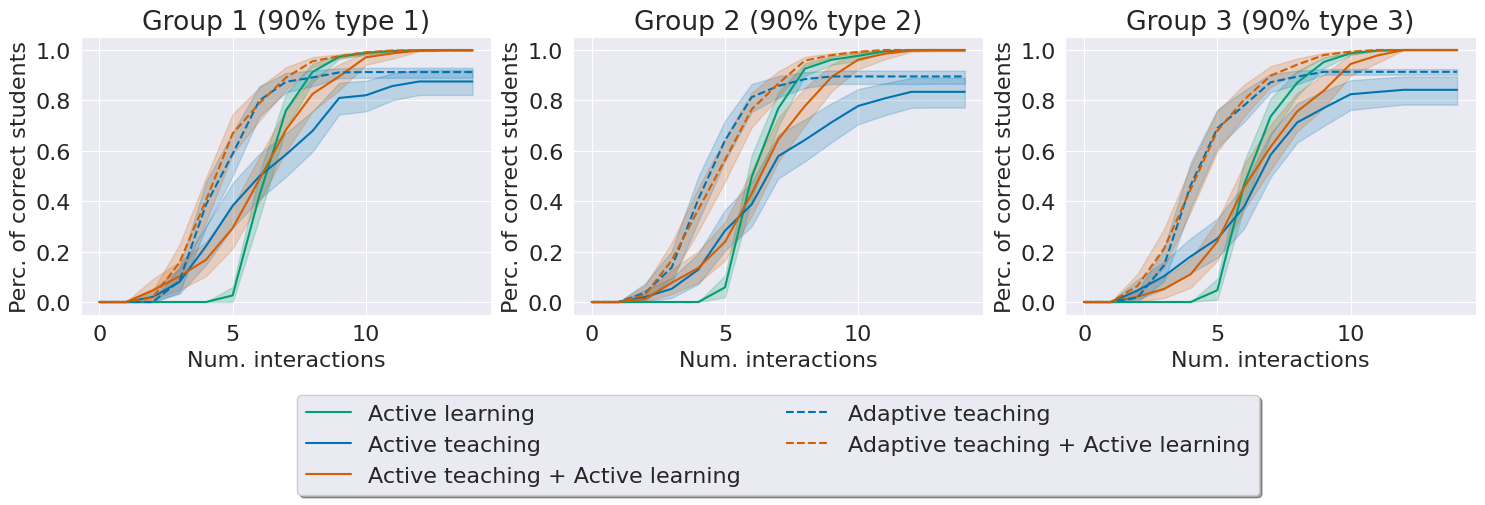

In [ ]:
fig_grp, axs_grp = plt.subplots(nrows=1, ncols=3, figsize=(18, 4))
# fig_grp.suptitle("Per-Group Performance Trajectories (Experience = 40)", fontsize=14, y=1.02)

group_labels = ["Group 1 (90% type 1)", "Group 2 (90% type 2)", "Group 3 (90% type 3)"]

strategy_data = {
    "Active learning": log_data_only_learn,
    "Active teaching": log_data_teach_non_adaptive,
    "Active teaching + Active learning": log_data_teach_learn_non_adaptive,
    "Adaptive teaching": log_data_teach_adaptive,
    "Adaptive teaching + Active learning": log_data_teach_learn_adaptive,
}

strategy_colors = {
    "Active teaching": (0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
    "Adaptive teaching": (0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
    "Active teaching + Active learning": (0.8352941176470589, 0.3686274509803922, 0.0),
    "Adaptive teaching + Active learning": (0.8352941176470589, 0.3686274509803922, 0.0),
    "Active learning": (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
}

strategy_linestyles = {
    "Active teaching": '-',
    "Adaptive teaching": '--',
    "Active teaching + Active learning": '-',
    "Adaptive teaching + Active learning": '--',
    "Active learning": '-',
}

exp_level_idx = 40  # Experienced teacher

for grp_idx in range(3):
    ax = axs_grp[grp_idx]
    for name, data in strategy_data.items():
        pds = data["percentage_of_done_students"]  # [100, 41, 3, 15]
        grp_data = pds[:, exp_level_idx, grp_idx, :]  # [100, 15]
        y_mean = np.mean(grp_data, axis=0)
        # y_std = np.std(grp_data, axis=0)

        line, = ax.plot(y_mean, label=name,
                color=strategy_colors[name],
                linestyle=strategy_linestyles[name])

        # Plot bootstrapped confidence interval.
        cis = nanmean_ci_cols(grp_data)
        ax.fill_between(np.arange(Nf_local), cis[:,0], cis[:,1], alpha=0.2, color=line.get_color())

    ax.set_title(group_labels[grp_idx])
    ax.set_xlabel("Num. interactions")
    ax.set_ylabel("Perc. of correct students")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True)


# LEGEND.
box = axs_grp[0].get_position()
axs_grp[0].set_position([box.x0, box.y0 + box.height * 0.1,
                 box.width, box.height * 0.9])
box = axs_grp[1].get_position()
axs_grp[1].set_position([box.x0, box.y0 + box.height * 0.1,
                 box.width, box.height * 0.9])
axs_grp[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.25),
          fancybox=True, shadow=True, ncol=2)
box = axs_grp[2].get_position()
axs_grp[2].set_position([box.x0, box.y0 + box.height * 0.1,
                 box.width, box.height * 0.9])

fig_grp.savefig("group_level_results.pdf", bbox_inches='tight')

### Group-level quantitative table

In [ ]:
# Per-group final % correct and steps to 100%, at experience=40.

rows_grp = []
exp_level_idx = 40

for grp_idx in range(3):
    for name, data in strategy_data.items():
        pds = data["percentage_of_done_students"]
        grp_data = pds[:, exp_level_idx, grp_idx, :]  # [100, 15]

        final_pct = grp_data[:, -1]  # [100]
        steps_list = []
        for run in range(grp_data.shape[0]):
            reached = np.where(grp_data[run, :] >= 0.999)[0]
            if len(reached) > 0:
                steps_list.append(reached[0] + 1)
            else:
                steps_list.append(np.nan)
        steps_arr = np.array(steps_list)

        rows_grp.append({
            "Group": f"Group {grp_idx+1}",
            "Interaction mode": name,
            "Final % correct (mean±SD)": f"{np.mean(final_pct)*100:.1f}±{np.std(final_pct)*100:.1f}%",
            "Reaches 100%": f"{np.mean(~np.isnan(steps_arr))*100:.0f}%",
            "Steps to 100% (mean±SD)": f"{np.nanmean(steps_arr):.1f}±{np.nanstd(steps_arr):.1f}" if np.any(~np.isnan(steps_arr)) else "N/A",
        })

df_grp = pd.DataFrame(rows_grp)
for grp_idx in range(3):
    print(f"\n--- Group {grp_idx+1} ---")
    sub = df_grp[df_grp["Group"] == f"Group {grp_idx+1}"].drop(columns=["Group"])
    print(sub.to_string(index=False))

df_grp.to_csv("group_level_results_table.csv", index=False)
print("\nSaved to group_level_results_table.csv")


--- Group 1 ---
                   Interaction mode Final % correct (mean±SD) Reaches 100% Steps to 100% (mean±SD)
                    Active learning                100.0±0.0%         100%                10.1±1.4
                    Active teaching                87.5±25.2%          25%                 8.8±2.8
  Active teaching + Active learning                 99.9±0.8%          97%                 9.6±2.0
                  Adaptive teaching                91.2±10.2%          13%                 7.4±2.1
Adaptive teaching + Active learning                 99.9±1.0%          99%                 9.1±2.1

--- Group 2 ---
                   Interaction mode Final % correct (mean±SD) Reaches 100% Steps to 100% (mean±SD)
                    Active learning                100.0±0.0%         100%                10.1±1.5
                    Active teaching                83.4±30.2%          28%                 8.5±2.5
  Active teaching + Active learning                 99.8±1.7%          99% 

### Robustness Analysis — Vary blind-spot severity

In [ ]:
print("Running with num_learner_disabled_features = 3, 5 (original), 7")

np.random.seed(45)

NUM_EXPS = 30

data_robustness_disabled = {}
for n_disabled in [3, 5, 7]:
    print(f"\n>>> Running with {n_disabled} disabled features...")

    interaction_f_args = {
        "S": 500,
        "num_interactions_with_groups": 41,
        "pf": np.array([0.2,0.3,0.4,0.5,0.6,0.7,0.1,0.4,0.4,0.9,0.8,0.7,0.5,0.6,0.2]),
        "num_learners_types": 3,
        "num_learner_disabled_features": n_disabled,
        "num_groups": 3,
        "num_students_per_group": 30,
        "prob_type_given_group": np.array([[0.9,0.05,0.05],[0.05,0.9,0.05],[0.05,0.05,0.9]]),
        "force_dataset_learnability": True,
        "adaptive_group_teaching": None,
        "interaction_f": None,
    }

    results = {}

    interaction_f_args["adaptive_group_teaching"] = True
    interaction_f_args["interaction_f"] = interact_with_group_only_teaching
    results["Adaptive teaching"] = run_multiple_exps(num_exps=NUM_EXPS, interaction_f_args=interaction_f_args)

    interaction_f_args["adaptive_group_teaching"] = False
    interaction_f_args["interaction_f"] = interact_with_group_only_teaching
    results["Active teaching"] = run_multiple_exps(num_exps=NUM_EXPS, interaction_f_args=interaction_f_args)

    interaction_f_args["adaptive_group_teaching"] = True
    interaction_f_args["interaction_f"] = interact_with_group_teaching_and_learning
    results["Adaptive teaching + Active learning"] = run_multiple_exps(num_exps=NUM_EXPS, interaction_f_args=interaction_f_args)

    interaction_f_args["adaptive_group_teaching"] = False
    interaction_f_args["interaction_f"] = interact_with_group_teaching_and_learning
    results["Active teaching + Active learning"] = run_multiple_exps(num_exps=NUM_EXPS, interaction_f_args=interaction_f_args)

    interaction_f_args["adaptive_group_teaching"] = False # This parameter is irrelevant when using only active learning.
    interaction_f_args["interaction_f"] = only_active_learning
    results["Active learning"] = run_multiple_exps(num_exps=NUM_EXPS, interaction_f_args=interaction_f_args)

    data_robustness_disabled[n_disabled] = results


Running with num_learner_disabled_features = 3, 5 (original), 7

>>> Running with 3 disabled features...
Generated dataset:
Nc: 270 Nf: 15
disabled_features_per_learner_type: [array([9, 8, 6]), array([9, 3, 7]), array([4, 0, 2])]
students_groups_types: {0: [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)], 1: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Generated dataset:
Nc: 282 Nf: 15
disabled_features_per_learner_type: [array([9, 2, 1]), array([6, 4, 3]), array([12,  6,  3])]
students_groups_types: {0: [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)], 1: [np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)], 2: [np.int64(2), np.int64(2), np.int64(2), np.int64(2), np

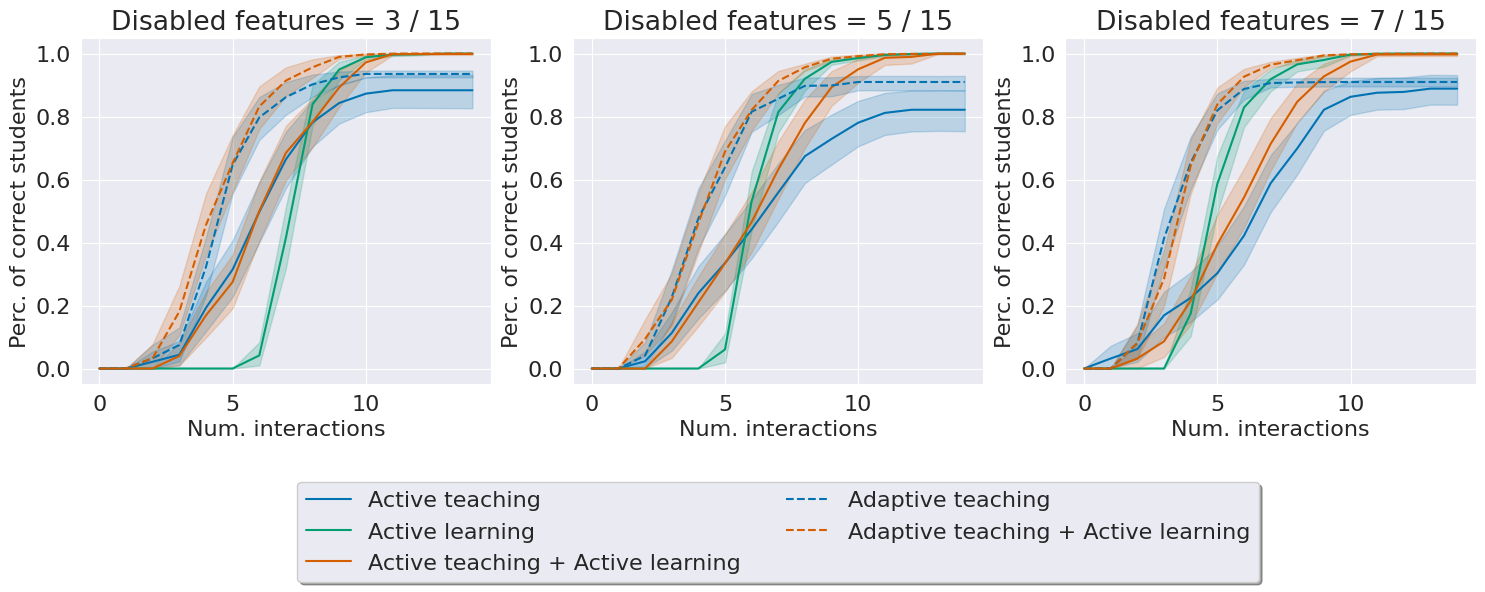

In [ ]:
# Plot robustness figure.
fig_rob, axs_rob = plt.subplots(1, 3, figsize=(18, 5))
# fig_rob.suptitle("Robustness: Effect of Blind-Spot Severity (Experience = 40)", fontsize=14, y=1.02)

lbls = ["Active teaching", "Active learning", "Active teaching + Active learning", "Adaptive teaching", "Adaptive teaching + Active learning"]

for ax_idx, n_disabled in enumerate([3, 5, 7]):
    ax = axs_rob[ax_idx]
    for name in lbls:
        pds = data_robustness_disabled[n_disabled][name]["percentage_of_done_students"]
        Nf_rob = pds.shape[-1]
        data_to_plot = pds[:, 40, :, :]  # experience=40
        data_to_plot = data_to_plot.reshape(-1, Nf_rob)
        y_mean = np.mean(data_to_plot, axis=0)
        line, = ax.plot(y_mean, label=name,
                color=strategy_colors[name],
                linestyle=strategy_linestyles[name])

        # Plot bootstrapped confidence interval.
        cis = nanmean_ci_cols(data_to_plot)
        ax.fill_between(np.arange(Nf_rob), cis[:,0], cis[:,1], alpha=0.2, color=line.get_color())

    ax.set_title(f"Disabled features = {n_disabled} / 15")
    ax.set_xlabel("Num. interactions")
    ax.set_ylabel("Perc. of correct students")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True)

# LEGEND.
box = axs_rob[0].get_position()
axs_rob[0].set_position([box.x0, box.y0 + box.height * 0.1,
                 box.width, box.height * 0.9])
box = axs_rob[1].get_position()
axs_rob[1].set_position([box.x0, box.y0 + box.height * 0.1,
                 box.width, box.height * 0.9])
axs_rob[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.25),
          fancybox=True, shadow=True, ncol=2)
box = axs_rob[2].get_position()
axs_rob[2].set_position([box.x0, box.y0 + box.height * 0.1,
                 box.width, box.height * 0.9])

fig_rob.savefig("robustness_blindspot_severity.pdf", bbox_inches='tight')

### Robustness Analysis — Vary group homogeneity

In [ ]:
np.random.seed(45)

NUM_EXPS = 30

homogeneity_configs = {
    "High (90/5/5)": np.array([[0.9,0.05,0.05],[0.05,0.9,0.05],[0.05,0.05,0.9]]),
    "Medium (60/20/20)": np.array([[0.6,0.2,0.2],[0.2,0.6,0.2],[0.2,0.2,0.6]]),
    "Uniform (34/33/33)": np.array([[0.34,0.33,0.33],[0.34,0.33,0.33],[0.34,0.33,0.33]]),
}

data_robustness_homogeneity = {}
for config_name, prob_matrix in homogeneity_configs.items():
    print(f"\n>>> Running with {config_name}...")

    interaction_f_args = {
        "S": 500,
        "num_interactions_with_groups": 41,
        "pf": np.array([0.2,0.3,0.4,0.5,0.6,0.7,0.1,0.4,0.4,0.9,0.8,0.7,0.5,0.6,0.2]),
        "num_learners_types": 3,
        "num_learner_disabled_features": 5,
        "num_groups": 3,
        "num_students_per_group": 30,
        "prob_type_given_group": prob_matrix,
        "force_dataset_learnability": True,
        "adaptive_group_teaching": None,
        "interaction_f": None,
    }

    results = {}

    interaction_f_args["adaptive_group_teaching"] = True
    interaction_f_args["interaction_f"] = interact_with_group_only_teaching
    results["Adaptive teaching"] = run_multiple_exps(num_exps=NUM_EXPS, interaction_f_args=interaction_f_args)

    interaction_f_args["adaptive_group_teaching"] = False
    interaction_f_args["interaction_f"] = interact_with_group_only_teaching
    results["Active teaching"] = run_multiple_exps(num_exps=NUM_EXPS, interaction_f_args=interaction_f_args)

    interaction_f_args["adaptive_group_teaching"] = True
    interaction_f_args["interaction_f"] = interact_with_group_teaching_and_learning
    results["Adaptive teaching + Active learning"] = run_multiple_exps(num_exps=NUM_EXPS, interaction_f_args=interaction_f_args)

    interaction_f_args["adaptive_group_teaching"] = False
    interaction_f_args["interaction_f"] = interact_with_group_teaching_and_learning
    results["Active teaching + Active learning"] = run_multiple_exps(num_exps=NUM_EXPS, interaction_f_args=interaction_f_args)

    interaction_f_args["adaptive_group_teaching"] = False # This parameter is irrelevant when using only active learning.
    interaction_f_args["interaction_f"] = only_active_learning
    results["Active learning"] = run_multiple_exps(num_exps=NUM_EXPS, interaction_f_args=interaction_f_args)

    data_robustness_homogeneity[config_name] = results


>>> Running with High (90/5/5)...
Generated dataset:
Nc: 138 Nf: 15
disabled_features_per_learner_type: [array([ 9,  8,  6,  2, 10]), array([ 9,  3,  7, 12, 11]), array([ 4,  0,  2,  7, 11])]
students_groups_types: {0: [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)], 1: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int6

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Generated dataset:
Nc: 132 Nf: 15
disabled_features_per_learner_type: [array([ 3, 11,  8, 12, 13]), array([13,  0,  7, 11, 14]), array([11, 13,  2,  4,  6])]
students_groups_types: {0: [np.int64(0), np.int64(2), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)], 1: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)], 2: [np.int64(2), np.int64(2)

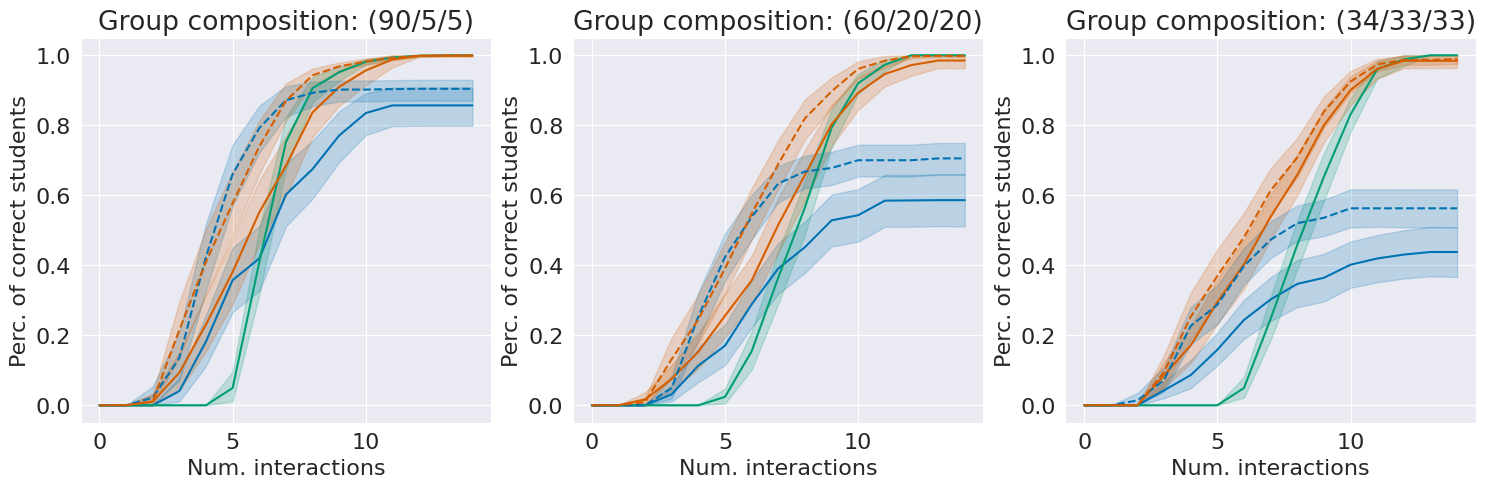

In [ ]:
fig_hom, axs_hom = plt.subplots(1, 3, figsize=(18, 5))
# fig_hom.suptitle("Robustness: Effect of Group Homogeneity (Experience = 40)", fontsize=14, y=1.02)

lbls = ["Active teaching", "Active learning", "Active teaching + Active learning", "Adaptive teaching", "Adaptive teaching + Active learning"]
title_lbs = {
    "High (90/5/5)": "(90/5/5)",
    "Medium (60/20/20)": "(60/20/20)",
    "Uniform (34/33/33)": "(34/33/33)",
}

for ax_idx, config_name in enumerate(homogeneity_configs.keys()):
    ax = axs_hom[ax_idx]
    for name in lbls:
        pds = data_robustness_homogeneity[config_name][name]["percentage_of_done_students"]
        Nf_rob = pds.shape[-1]
        data_to_plot = pds[:, 40, :, :]
        data_to_plot = data_to_plot.reshape(-1, Nf_rob)
        y_mean = np.mean(data_to_plot, axis=0)
        line, = ax.plot(y_mean, label=name,
                color=strategy_colors[name],
                linestyle=strategy_linestyles[name])

        # Plot bootstrapped confidence interval.
        cis = nanmean_ci_cols(data_to_plot)
        ax.fill_between(np.arange(Nf_rob), cis[:,0], cis[:,1], alpha=0.2, color=line.get_color())

    ax.set_title(f"Group composition: {title_lbs[config_name]}")
    ax.set_xlabel("Num. interactions")
    ax.set_ylabel("Perc. of correct students")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True)

# LEGEND.
box = axs_rob[0].get_position()
axs_rob[0].set_position([box.x0, box.y0 + box.height * 0.1,
                 box.width, box.height * 0.9])
box = axs_rob[1].get_position()
axs_rob[1].set_position([box.x0, box.y0 + box.height * 0.1,
                 box.width, box.height * 0.9])
axs_rob[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.25),
          fancybox=True, shadow=True, ncol=2)
box = axs_rob[2].get_position()
axs_rob[2].set_position([box.x0, box.y0 + box.height * 0.1,
                 box.width, box.height * 0.9])

fig_hom.savefig("robustness_group_homogeneity.pdf", bbox_inches='tight')

### Robustness summary table

In [ ]:
rows_rob = []
for n_disabled in [3, 5, 7]:
    for name in lbls:
        pds = data_robustness_disabled[n_disabled][name]["percentage_of_done_students"]
        Nf_rob = pds.shape[-1]
        data_exp40 = pds[:, 40, :, :]  # [50, 3, Nf]

        final_pct = data_exp40[:, :, -1].reshape(-1)  # [150]

        steps_list = []
        for run in range(data_exp40.shape[0]):
            for grp in range(data_exp40.shape[1]):
                traj = data_exp40[run, grp, :]
                reached = np.where(traj >= 0.999)[0]
                steps_list.append(reached[0] + 1 if len(reached) > 0 else np.nan)
        steps_arr = np.array(steps_list)

        rows_rob.append({
            "Disabled features": n_disabled,
            "Interaction mode": name,
            "Final % correct": f"{np.mean(final_pct)*100:.1f}±{np.std(final_pct)*100:.1f}%",
            "Reaches 100%": f"{np.mean(~np.isnan(steps_arr))*100:.0f}%",
            "Steps to 100%": f"{np.nanmean(steps_arr):.1f}±{np.nanstd(steps_arr):.1f}" if np.any(~np.isnan(steps_arr)) else "N/A",
        })

df_rob = pd.DataFrame(rows_rob)
print("=" * 80)
print("ROBUSTNESS TABLE: Blind-spot severity (Experience = 40)")
print("=" * 80)
for nd in [3, 5, 7]:
    print(f"\n--- {nd} disabled features out of 15 ---")
    sub = df_rob[df_rob["Disabled features"] == nd].drop(columns=["Disabled features"])
    print(sub.to_string(index=False))

df_rob.to_csv("robustness_blindspot_table.csv", index=False)
print("\nSaved to robustness_blindspot_table.csv")

ROBUSTNESS TABLE: Blind-spot severity (Experience = 40)

--- 3 disabled features out of 15 ---
                   Interaction mode Final % correct Reaches 100% Steps to 100%
                    Active teaching      88.3±25.4%          37%       7.4±2.0
                    Active learning      100.0±0.0%         100%      10.2±1.4
  Active teaching + Active learning       99.9±1.4%          99%       9.6±1.8
                  Adaptive teaching       93.5±5.2%          21%       6.1±1.9
Adaptive teaching + Active learning      100.0±0.0%         100%       8.0±2.3

--- 5 disabled features out of 15 ---
                   Interaction mode Final % correct Reaches 100% Steps to 100%
                    Active teaching      82.1±31.5%          34%       8.0±2.7
                    Active learning      100.0±0.0%         100%      10.2±1.5
  Active teaching + Active learning      100.0±0.0%         100%       9.8±2.0
                  Adaptive teaching      91.0±11.2%          16%       6.3±2